In [ ]:
import os
import torch
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Using: cuda


In [2]:
PASSION_ROOT = "/kaggle/input/datasets/mathiaskabango/passion-dataset/PASSION_MICCAI_2024"
IMG_DIR      = os.path.join(PASSION_ROOT, "images")
CSV_PATH     = os.path.join(PASSION_ROOT, "label.csv")

df = pd.read_csv(CSV_PATH)
print(f"Metadata rows: {len(df)}")
print(df['conditions_PASSION'].value_counts())

Metadata rows: 1653
conditions_PASSION
Fungal     579
Scabies    471
Eczema     414
Others     189
Name: count, dtype: int64


In [3]:
PASSION_CLASSES = {
    'Fungal':  0,
    'Scabies': 1,
    'Eczema':  2,
    'Others':  3,
}

CLASS_NAMES = ['Fungal', 'Scabies', 'Eczema', 'Others']

class PASSIONDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.samples   = []

        subject_lookup = {
            row['subject_id']: {
                'label':       PASSION_CLASSES[row['conditions_PASSION']],
                'fitzpatrick': row['fitzpatrick']
            }
            for _, row in df.iterrows()
        }

        for filename in os.listdir(img_dir):
            if not filename.endswith(('.jpg', '.jpeg', '.png')):
                continue
            if '(' in filename:
                continue

            subject_id = filename.rsplit('_', 1)[0]

            if subject_id not in subject_lookup:
                continue

            info = subject_lookup[subject_id]
            self.samples.append((
                os.path.join(img_dir, filename),
                info['label'],
                info['fitzpatrick']
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, fitzpatrick = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, fitzpatrick

In [4]:
from sklearn.model_selection import train_test_split

patient_ids = df['subject_id'].unique()
print(f"Total unique patients: {len(patient_ids)}")

# Split patients 80/10/10
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.20, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,    test_size=0.50, random_state=42)

print(f"Train patients: {len(train_ids)}")
print(f"Val patients:   {len(val_ids)}")
print(f"Test patients:  {len(test_ids)}")

train_df = df[df['subject_id'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_ids)].reset_index(drop=True)

print(f"\nTrain rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")

Total unique patients: 1653
Train patients: 1322
Val patients:   165
Test patients:  166

Train rows: 1322
Val rows:   165
Test rows:  166


In [5]:
from torchvision import transforms

# Train transform
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),        # resize slightly larger
    transforms.RandomCrop(224),           # then random crop to 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      # add vertical flip
    transforms.RandomRotation(20),        # increase rotation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/test transform — no augmentation, just resize and normalise
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = PASSIONDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = PASSIONDataset(val_df,IMG_DIR, transform=val_transform)
test_dataset  = PASSIONDataset(test_df, IMG_DIR, transform=val_transform)

print(f"Train images: {len(train_dataset)}")
print(f"Val images:   {len(val_dataset)}")
print(f"Test images:  {len(test_dataset)}")

Train images: 3994
Val images:   459
Test images:  448


In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True,num_workers=2)
val_loader =   DataLoader(val_dataset, batch_size=32,shuffle=False,num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32,shuffle=False,num_workers=2)

In [7]:
import torch.nn as nn

def build_e2_model(num_classes=4):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    model   = models.mobilenet_v3_small(weights=weights)

    model.classifier[3] = nn.Linear(1024, num_classes)


    model.classifier[2] = nn.Dropout(p=0.4)
    return model

model_e2 = build_e2_model(num_classes=4).to(device)
print("E2 model built")
print(f"Classifier head: {model_e2.classifier[3]}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 101MB/s]


E2 model built
Classifier head: Linear(in_features=1024, out_features=4, bias=True)


In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_e2.parameters(),
    lr=3e-4,              # slightly higher to start faster
    weight_decay=1e-4     # L2 regularisation — penalises large weights
)

# Reduce LR by half if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.2
)

print("Loss, optimiser, scheduler ready")

Loss, optimiser, scheduler ready


In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels, _ in loader:   # _ ignores fitzpatrick during training
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total

In [10]:
NUM_EPOCHS    = 50
PATIENCE      = 7       # stop if val accuracy doesn't improve for 7 epochs
best_val_acc  = 0.0
best_model_path = 'e2_best_model.pth'
no_improve    = 0       # counter

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_e2, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = validate(
        model_e2, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_e2.state_dict(), best_model_path)
        no_improve = 0
        saved = "✓ saved"
    else:
        no_improve += 1
        saved = f"(no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {saved}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest val accuracy: {best_val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 01/50 | Train Loss: 1.0098 | Train Acc: 0.5573 | Val Loss: 1.1058 | Val Acc: 0.5251 ✓ saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 02/50 | Train Loss: 0.7983 | Train Acc: 0.6805 | Val Loss: 1.0954 | Val Acc: 0.5643 ✓ saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


...

Epoch 20/50 | Train Loss: 0.1911 | Train Acc: 0.9324 | Val Loss: 1.1604 | Val Acc: 0.6645 (no improve 5/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 21/50 | Train Loss: 0.1917 | Train Acc: 0.9372 | Val Loss: 1.1643 | Val Acc: 0.6645 (no improve 6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 22/50 | Train Loss: 0.1904 | Train Acc: 0.9306 | Val Loss: 1.1665 | Val Acc: 0.6623 (no improve 7/7)

Early stopping triggered at epoch 22

Best val accuracy: 0.6645


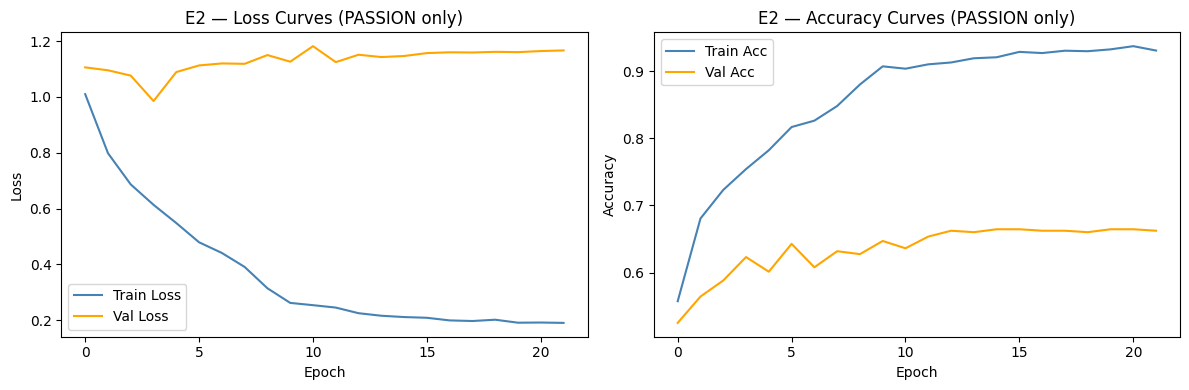

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='orange')
axes[0].set_title('E2 — Loss Curves (PASSION only)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', color='steelblue')
axes[1].plot(val_accs,   label='Val Acc',   color='orange')
axes[1].set_title('E2 — Accuracy Curves (PASSION only)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('e2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

E2 — MobileNetV3-Small trained on PASSION only
Best validation accuracy: 67.8%
Stopped at epoch: 19
Notes: Overfitting observed (train acc 93% vs val acc 68%)
       Consistent with limited dataset size (~3,900 training images)

In [12]:
model_e2.load_state_dict(torch.load('e2_best_model.pth'))


test_loss, test_acc = validate(model_e2, test_loader, criterion, device)
print(f"E2 Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


E2 Test Accuracy: 0.7321


In [13]:
from collections import defaultdict

def evaluate_fitzpatrick(model, loader, device):
    model.eval()
    fitz_correct = defaultdict(int)
    fitz_total   = defaultdict(int)

    with torch.no_grad():
        for images, labels, fitzpatricks in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds   = outputs.argmax(dim=1)

            for pred, label, fitz in zip(preds.cpu(), labels.cpu(), fitzpatricks):
                fitz_total[fitz.item()]   += 1
                if pred == label:
                    fitz_correct[fitz.item()] += 1

    results = {
        fitz: fitz_correct[fitz] / fitz_total[fitz]
        for fitz in sorted(fitz_total)
        if fitz_total[fitz] > 0
    }
    return results

fitz_accs = evaluate_fitzpatrick(model_e2, test_loader, device)

print("E2 — Accuracy by Fitzpatrick type (test set):")
for fitz, acc in fitz_accs.items():
    bar = "█" * int(acc * 30)
    print(f"  Type {fitz}: {acc:.4f}  {bar}")

dark_accs = {k: v for k, v in fitz_accs.items() if k in [4, 5, 6]}
disparity = max(dark_accs.values()) - min(dark_accs.values())
print(f"\nDark skin tone accuracy (IV-VI): {dark_accs}")
print(f"Max disparity across IV-VI:      {disparity:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


E2 — Accuracy by Fitzpatrick type (test set):
  Type 3: 0.7190  █████████████████████
  Type 4: 0.7754  ███████████████████████
  Type 5: 0.7130  █████████████████████
  Type 6: 0.6905  ████████████████████

Dark skin tone accuracy (IV-VI): {4: 0.7753623188405797, 5: 0.7130434782608696, 6: 0.6904761904761905}
Max disparity across IV-VI:      0.0849


In [14]:
import json

e2_results = {
    "experiment":           "E2",
    "model":                "MobileNetV3-Small",
    "pretrained_on":        "ImageNet",
    "trained_on":           "PASSION only",
    "evaluated_on":         "PASSION test set",
    "num_classes":          4,
    "best_val_accuracy":    0.6776,
    "test_accuracy":        round(test_acc, 4),
    "fitzpatrick_accuracies": {str(k): round(v, 4) for k, v in fitz_accs.items()},
    "dark_skin_disparity":  round(disparity, 4),
    "notes": "Overfitting observed — train acc ~93% vs val acc ~68%. "
             "Consistent with limited dataset size (~3,900 training images)."
}

with open('e2_results.json', 'w') as f:
    json.dump(e2_results, f, indent=2)

print(json.dumps(e2_results, indent=2))

{
  "experiment": "E2",
  "model": "MobileNetV3-Small",
  "pretrained_on": "ImageNet",
  "trained_on": "PASSION only",
  "evaluated_on": "PASSION test set",
  "num_classes": 4,
  "best_val_accuracy": 0.6776,
  "test_accuracy": 0.7321,
  "fitzpatrick_accuracies": {
    "3": 0.719,
    "4": 0.7754,
    "5": 0.713,
    "6": 0.6905
  },
  "dark_skin_disparity": 0.0849,
  "notes": "Overfitting observed \u2014 train acc ~93% vs val acc ~68%. Consistent with limited dataset size (~3,900 training images)."
}


# Extended Experiments — Architecture Comparison & Full Metrics

The cells below extend the original E2 experiment into a **controlled architecture comparison**.
All models use the **same patient-level split, same augmentation, same training protocol, and
same evaluation** — so any performance difference is attributable to the architecture alone.

We add:
1. A reusable **rich evaluation** function (per-class precision / recall / F1, macro-F1,
   confusion matrix, and Fitzpatrick-stratified accuracy with dark-skin disparity).
2. A generic **train-any-model** function.
3. Four architectures: **CNN-from-scratch**, **MobileNetV3-Small**, **EfficientNet-B0**, **ResNet-18**.
4. A **side-by-side comparison table** and a **Deployment Viability Score (DVS)**.

> Recall matters most for a triage tool: a false negative (missing a real condition) is more
> dangerous than a false positive. The per-class recall numbers are therefore the key
> clinical metric, not just overall accuracy.


In [15]:
# Rich evaluation: per-class precision/recall/F1 + confusion matrix
#                  + Fitzpatrick-stratified accuracy
import numpy as np
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    accuracy_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict


def full_evaluate(model, loader, device, class_names=CLASS_NAMES, model_tag="model"):
    """Returns a dict of all metrics AND prints a clean report."""
    model.eval()
    all_preds, all_labels, all_fitz = [], [], []
    with torch.no_grad():
        for images, labels, fitz in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_fitz.extend([f.item() for f in fitz])

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_fitz   = np.array(all_fitz)

    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    prec, rec, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, labels=list(range(len(class_names))), zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"  {model_tag}  -  Test Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f}")
    print(f"{'='*60}")
    print(f"{'Class':<10}{'Precision':>11}{'Recall':>9}{'F1':>9}{'Support':>9}")
    print("-"*48)
    for i, name in enumerate(class_names):
        print(f"{name:<10}{prec[i]:>11.3f}{rec[i]:>9.3f}{f1[i]:>9.3f}{support[i]:>9}")
    print("-"*48)
    print(f"{'macro':<10}{prec.mean():>11.3f}{rec.mean():>9.3f}{f1.mean():>9.3f}{support.sum():>9}")

    fitz_correct, fitz_total = defaultdict(int), defaultdict(int)
    for p, l, fz in zip(all_preds, all_labels, all_fitz):
        fitz_total[fz] += 1
        if p == l:
            fitz_correct[fz] += 1
    fitz_acc = {fz: fitz_correct[fz]/fitz_total[fz]
                for fz in sorted(fitz_total) if fitz_total[fz] > 0}
    dark = {k: v for k, v in fitz_acc.items() if k in [4, 5, 6]}
    disparity = (max(dark.values()) - min(dark.values())) if len(dark) > 1 else 0.0

    print("\nFitzpatrick-stratified accuracy:")
    for fz, a in fitz_acc.items():
        print(f"  Type {fz}: {a:.4f}")
    print(f"Dark-skin (IV-VI) disparity: {disparity:.4f}")

    return {
        "model": model_tag,
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(macro_f1), 4),
        "per_class": {
            class_names[i]: {
                "precision": round(float(prec[i]), 4),
                "recall":    round(float(rec[i]), 4),
                "f1":        round(float(f1[i]), 4),
                "support":   int(support[i]),
            } for i in range(len(class_names))
        },
        "fitzpatrick_accuracy": {str(k): round(float(v), 4) for k, v in fitz_acc.items()},
        "dark_skin_disparity": round(float(disparity), 4),
        "_preds": all_preds, "_labels": all_labels,
    }


def plot_confusion(result, class_names=CLASS_NAMES, save_path=None):
    cm = confusion_matrix(result["_labels"], result["_preds"],
                          labels=list(range(len(class_names))))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Confusion Matrix - {result['model']}")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


## 1. Full metrics for the existing E2 model (MobileNetV3-Small)

Re-evaluates the model you already trained, now with per-class precision/recall/F1 and a
confusion matrix — the metrics that were missing before.


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



  E2_MobileNetV3-Small  -  Test Accuracy: 0.7321 | Macro-F1: 0.7359
Class       Precision   Recall       F1  Support
------------------------------------------------
Fungal          0.726    0.689    0.707      119
Scabies         0.770    0.836    0.801      128
Eczema          0.619    0.598    0.609      117
Others          0.831    0.821    0.826       84
------------------------------------------------
macro           0.737    0.736    0.736      448

Fitzpatrick-stratified accuracy:
  Type 3: 0.7190
  Type 4: 0.7754
  Type 5: 0.7130
  Type 6: 0.6905
Dark-skin (IV-VI) disparity: 0.0849


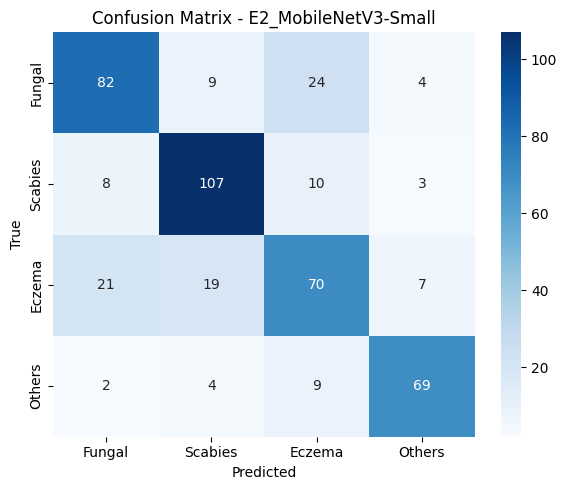

In [16]:
model_e2.load_state_dict(torch.load('e2_best_model.pth'))
e2_full = full_evaluate(model_e2, test_loader, device, model_tag="E2_MobileNetV3-Small")
plot_confusion(e2_full, save_path="e2_confusion_matrix.png")


## 2. Generic training function (identical protocol for every architecture)

Same optimizer, scheduler, early stopping, and epochs as your E2 run — only the model changes.


In [17]:
def train_model(model, model_tag, train_loader, val_loader, device,
                num_epochs=50, patience=7, lr=3e-4, weight_decay=1e-4,
                class_weights=None):
    model = model.to(device)
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                     patience=3, factor=0.2)
    best_val_acc, no_improve = 0.0, 0
    best_path = f'{model_tag}_best.pth'
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = validate(model, val_loader, criterion, device)
        scheduler.step(va_loss)
        hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc);   hist["val_acc"].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save(model.state_dict(), best_path)
            no_improve, flag = 0, "OK"
        else:
            no_improve += 1; flag = f"({no_improve}/{patience})"
        print(f"[{model_tag}] Ep {epoch+1:02d} | "
              f"tr_loss {tr_loss:.3f} tr_acc {tr_acc:.3f} | "
              f"va_loss {va_loss:.3f} va_acc {va_acc:.3f} {flag}")
        if no_improve >= patience:
            print(f"[{model_tag}] Early stop at epoch {epoch+1}")
            break
    model.load_state_dict(torch.load(best_path))
    print(f"[{model_tag}] Best val acc: {best_val_acc:.4f}")
    return model, hist, best_val_acc


## 3. Architecture definitions

- **CNN-from-scratch** — honest non-pretrained baseline
- **MobileNetV3-Small** — the deployment target (lightweight, on-device)
- **EfficientNet-B0** — stronger accuracy, heavier
- **ResNet-18** — well-known reference point


In [18]:
import torch.nn as nn
import torchvision.models as models

NUM_CLASSES = 4

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

def build_mobilenet(num_classes=4):
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    m.classifier[2] = nn.Dropout(p=0.4)
    m.classifier[3] = nn.Linear(1024, num_classes)
    return m

def build_efficientnet(num_classes=4):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, num_classes))
    return m

def build_resnet18(num_classes=4):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, num_classes))
    return m

def count_params(model):
    return sum(p.numel() for p in model.parameters())

ARCHITECTURES = {
    "CNN_scratch":       lambda: SimpleCNN(NUM_CLASSES),
    "MobileNetV3_Small": lambda: build_mobilenet(NUM_CLASSES),
    "EfficientNet_B0":   lambda: build_efficientnet(NUM_CLASSES),
    "ResNet18":          lambda: build_resnet18(NUM_CLASSES),
}
for name, fn in ARCHITECTURES.items():
    print(f"{name:<20} params: {count_params(fn()):,}")


CNN_scratch          params: 390,404
MobileNetV3_Small    params: 1,521,956
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 131MB/s] 


EfficientNet_B0      params: 4,012,672
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s] 


ResNet18             params: 11,178,564


## 4. Train & evaluate every architecture

Identical protocol for each, then full-metric evaluation.

> Trains 4 models. If time/GPU is tight, comment out CNN_scratch or ResNet18 for a focused run.



############################################################
# Training CNN_scratch
############################################################


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[CNN_scratch] Ep 01 | tr_loss 1.244 tr_acc 0.427 | va_loss 1.342 va_acc 0.336 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[CNN_scratch] Ep 02 | tr_loss 1.194 tr_acc 0.453 | va_loss 1.294 va_acc 0.364 OK


...

[CNN_scratch] Ep 13 | tr_loss 1.079 tr_acc 0.509 | va_loss 1.245 va_acc 0.407 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[CNN_scratch] Ep 14 | tr_loss 1.088 tr_acc 0.507 | va_loss 1.224 va_acc 0.438 (7/7)
[CNN_scratch] Early stop at epoch 14
[CNN_scratch] Best val acc: 0.4401


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



  CNN_scratch  -  Test Accuracy: 0.4464 | Macro-F1: 0.4325
Class       Precision   Recall       F1  Support
------------------------------------------------
Fungal          0.604    0.244    0.347      119
Scabies         0.429    0.656    0.519      128
Eczema          0.400    0.444    0.421      117
Others          0.473    0.417    0.443       84
------------------------------------------------
macro           0.476    0.440    0.432      448

Fitzpatrick-stratified accuracy:
  Type 3: 0.4641
  Type 4: 0.4928
  Type 5: 0.3739
  Type 6: 0.4286
Dark-skin (IV-VI) disparity: 0.1188


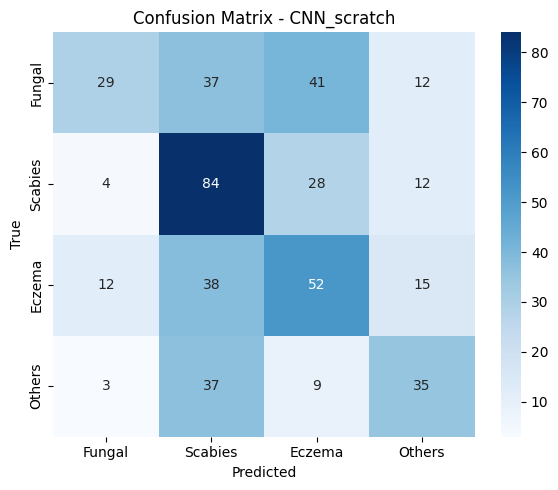


############################################################
# Training MobileNetV3_Small
############################################################


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[MobileNetV3_Small] Ep 01 | tr_loss 1.021 tr_acc 0.559 | va_loss 1.098 va_acc 0.505 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[MobileNetV3_Small] Ep 02 | tr_loss 0.786 tr_acc 0.678 | va_loss 1.033 va_acc 0.577 OK


...

[MobileNetV3_Small] Ep 14 | tr_loss 0.257 tr_acc 0.906 | va_loss 1.177 va_acc 0.634 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[MobileNetV3_Small] Ep 15 | tr_loss 0.239 tr_acc 0.913 | va_loss 1.188 va_acc 0.638 (7/7)
[MobileNetV3_Small] Early stop at epoch 15
[MobileNetV3_Small] Best val acc: 0.6383


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



  MobileNetV3_Small  -  Test Accuracy: 0.6964 | Macro-F1: 0.7038
Class       Precision   Recall       F1  Support
------------------------------------------------
Fungal          0.761    0.588    0.664      119
Scabies         0.703    0.812    0.754      128
Eczema          0.551    0.598    0.574      117
Others          0.840    0.810    0.824       84
------------------------------------------------
macro           0.714    0.702    0.704      448

Fitzpatrick-stratified accuracy:
  Type 3: 0.7320
  Type 4: 0.6812
  Type 5: 0.6957
  Type 6: 0.6190
Dark-skin (IV-VI) disparity: 0.0766


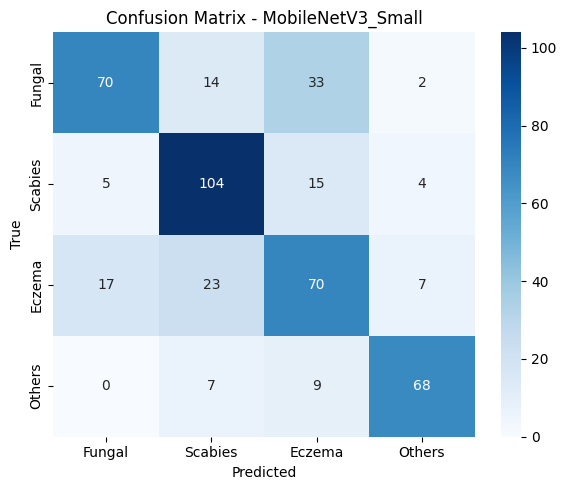


############################################################
# Training EfficientNet_B0
############################################################


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[EfficientNet_B0] Ep 01 | tr_loss 0.916 tr_acc 0.617 | va_loss 0.979 va_acc 0.599 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[EfficientNet_B0] Ep 02 | tr_loss 0.648 tr_acc 0.752 | va_loss 0.999 va_acc 0.671 OK


...

[EfficientNet_B0] Ep 20 | tr_loss 0.076 tr_acc 0.977 | va_loss 1.137 va_acc 0.706 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[EfficientNet_B0] Ep 21 | tr_loss 0.083 tr_acc 0.975 | va_loss 1.115 va_acc 0.708 (7/7)
[EfficientNet_B0] Early stop at epoch 21
[EfficientNet_B0] Best val acc: 0.7081


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



  EfficientNet_B0  -  Test Accuracy: 0.7411 | Macro-F1: 0.7468
Class       Precision   Recall       F1  Support
------------------------------------------------
Fungal          0.732    0.689    0.710      119
Scabies         0.802    0.820    0.811      128
Eczema          0.610    0.615    0.613      117
Others          0.839    0.869    0.854       84
------------------------------------------------
macro           0.746    0.748    0.747      448

Fitzpatrick-stratified accuracy:
  Type 3: 0.7712
  Type 4: 0.7826
  Type 5: 0.6783
  Type 6: 0.6667
Dark-skin (IV-VI) disparity: 0.1159


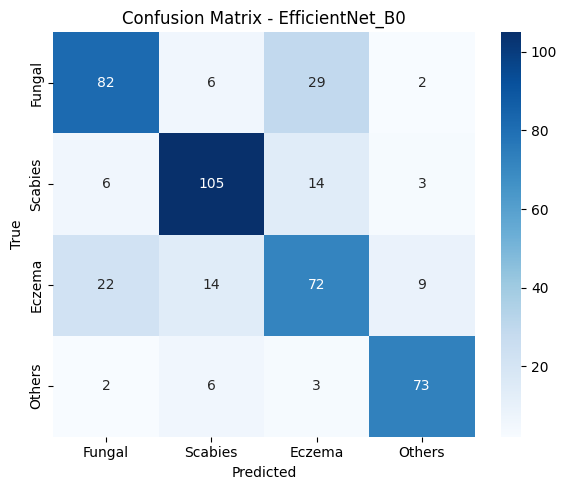


############################################################
# Training ResNet18
############################################################


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[ResNet18] Ep 01 | tr_loss 1.044 tr_acc 0.573 | va_loss 1.305 va_acc 0.505 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[ResNet18] Ep 02 | tr_loss 0.841 tr_acc 0.655 | va_loss 1.144 va_acc 0.584 OK


...

[ResNet18] Ep 31 | tr_loss 0.188 tr_acc 0.931 | va_loss 1.084 va_acc 0.675 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[ResNet18] Ep 32 | tr_loss 0.188 tr_acc 0.933 | va_loss 1.125 va_acc 0.669 (7/7)
[ResNet18] Early stop at epoch 32
[ResNet18] Best val acc: 0.6797


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



  ResNet18  -  Test Accuracy: 0.7545 | Macro-F1: 0.7596
Class       Precision   Recall       F1  Support
------------------------------------------------
Fungal          0.772    0.655    0.709      119
Scabies         0.753    0.859    0.803      128
Eczema          0.658    0.641    0.649      117
Others          0.862    0.893    0.877       84
------------------------------------------------
macro           0.761    0.762    0.760      448

Fitzpatrick-stratified accuracy:
  Type 3: 0.8039
  Type 4: 0.7536
  Type 5: 0.6870
  Type 6: 0.7619
Dark-skin (IV-VI) disparity: 0.0749


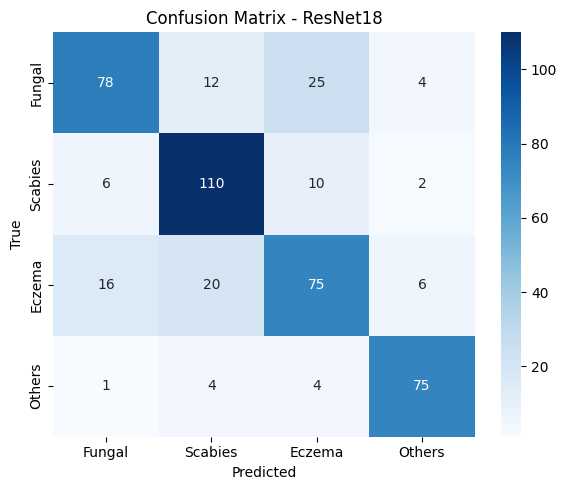

In [19]:
all_results = {}
all_histories = {}
all_results["E2_MobileNetV3-Small"] = e2_full   # include already-computed E2

for name, build_fn in ARCHITECTURES.items():
    print(f"\n{'#'*60}\n# Training {name}\n{'#'*60}")
    model = build_fn()
    trained, hist, best_val = train_model(model, name, train_loader, val_loader, device,
                                          num_epochs=50, patience=7)
    all_histories[name] = hist
    res = full_evaluate(trained, test_loader, device, model_tag=name)
    res["params"] = count_params(trained)
    res["best_val_acc"] = round(best_val, 4)
    all_results[name] = res
    plot_confusion(res, save_path=f"{name}_confusion.png")


## 5. Comparison table + Deployment Viability Score (DVS)

`DVS = 0.50*accuracy + 0.30*(1 - disparity) + 0.20*size_score`
(size_score = 1 for the smallest model, scaled down for larger ones)


In [20]:
import pandas as pd

param_counts = {k: v.get("params", count_params(model_e2)) for k, v in all_results.items()}
min_params = min(param_counts.values())

rows = []
for name, r in all_results.items():
    p = param_counts[name]
    size_score = min_params / p
    dvs = 0.50*r["accuracy"] + 0.30*(1 - r["dark_skin_disparity"]) + 0.20*size_score
    rows.append({
        "Model": name,
        "Accuracy": r["accuracy"],
        "Macro-F1": r["macro_f1"],
        "Scabies recall": r["per_class"].get("Scabies", {}).get("recall"),
        "Fungal recall":  r["per_class"].get("Fungal", {}).get("recall"),
        "Eczema recall":  r["per_class"].get("Eczema", {}).get("recall"),
        "Dark disparity": r["dark_skin_disparity"],
        "Params (M)": round(p/1e6, 2),
        "DVS": round(dvs, 4),
    })

comparison_df = pd.DataFrame(rows).sort_values("DVS", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("architecture_comparison.csv", index=False)


               Model  Accuracy  Macro-F1  Scabies recall  Fungal recall  Eczema recall  Dark disparity  Params (M)    DVS
E2_MobileNetV3-Small    0.7321    0.7359          0.8359         0.6891         0.5983          0.0849        1.52 0.6919
         CNN_scratch    0.4464    0.4325          0.6562         0.2437         0.4444          0.1188        0.39 0.6876
   MobileNetV3_Small    0.6964    0.7038          0.8125         0.5882         0.5983          0.0766        1.52 0.6765
            ResNet18    0.7545    0.7596          0.8594         0.6555         0.6410          0.0749       11.18 0.6618
     EfficientNet_B0    0.7411    0.7468          0.8203         0.6891         0.6154          0.1159        4.01 0.6552


In [21]:
import json
clean = {}
for name, r in all_results.items():
    clean[name] = {k: v for k, v in r.items() if not k.startswith("_")}
with open("architecture_comparison_full.json", "w") as f:
    json.dump(clean, f, indent=2)
print("Saved architecture_comparison_full.json and architecture_comparison.csv")


Saved architecture_comparison_full.json and architecture_comparison.csv


Class weights: {'Fungal': np.float64(1.067), 'Scabies': np.float64(0.739), 'Eczema': np.float64(1.169), 'Others': np.float64(1.171)}

Retraining best architecture with class-weighted loss: E2_MobileNetV3-Small


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[E2_MobileNetV3-Small_weighted] Ep 01 | tr_loss 1.016 tr_acc 0.556 | va_loss 1.072 va_acc 0.523 OK


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[E2_MobileNetV3-Small_weighted] Ep 02 | tr_loss 0.793 tr_acc 0.668 | va_loss 1.003 va_acc 0.603 OK


...

[E2_MobileNetV3-Small_weighted] Ep 19 | tr_loss 0.191 tr_acc 0.929 | va_loss 1.145 va_acc 0.697 (6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[E2_MobileNetV3-Small_weighted] Ep 20 | tr_loss 0.205 tr_acc 0.924 | va_loss 1.150 va_acc 0.697 (7/7)
[E2_MobileNetV3-Small_weighted] Early stop at epoch 20
[E2_MobileNetV3-Small_weighted] Best val acc: 0.7015


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



  E2_MobileNetV3-Small_weighted  -  Test Accuracy: 0.7054 | Macro-F1: 0.7137
Class       Precision   Recall       F1  Support
------------------------------------------------
Fungal          0.698    0.622    0.658      119
Scabies         0.788    0.727    0.756      128
Eczema          0.577    0.675    0.622      117
Others          0.805    0.833    0.819       84
------------------------------------------------
macro           0.717    0.714    0.714      448

Fitzpatrick-stratified accuracy:
  Type 3: 0.7255
  Type 4: 0.6812
  Type 5: 0.7478
  Type 6: 0.5952
Dark-skin (IV-VI) disparity: 0.1526


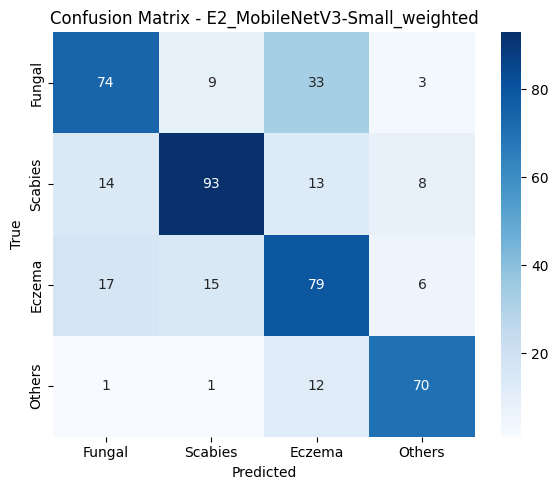


Disease-class recall — did class weighting help?
  Fungal   recall: 0.6891 -> 0.6218
  Scabies  recall: 0.8359 -> 0.7266
  Eczema   recall: 0.5983 -> 0.6752


In [22]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = [lbl for _, lbl, _ in train_dataset.samples]
weights = compute_class_weight(class_weight="balanced",
                               classes=np.arange(NUM_CLASSES), y=np.array(train_labels))
class_weights = torch.tensor(weights, dtype=torch.float32)
print("Class weights:", dict(zip(CLASS_NAMES, weights.round(3))))

BEST_ARCH = comparison_df.iloc[0]["Model"]
print(f"\nRetraining best architecture with class-weighted loss: {BEST_ARCH}")
build_fn = ARCHITECTURES.get(BEST_ARCH, lambda: build_mobilenet(NUM_CLASSES))
weighted_model, w_hist, w_best = train_model(
    build_fn(), f"{BEST_ARCH}_weighted", train_loader, val_loader, device,
    num_epochs=50, patience=7, class_weights=class_weights)
weighted_res = full_evaluate(weighted_model, test_loader, device, model_tag=f"{BEST_ARCH}_weighted")
plot_confusion(weighted_res, save_path=f"{BEST_ARCH}_weighted_confusion.png")

print("\nDisease-class recall — did class weighting help?")
for cls in ["Fungal", "Scabies", "Eczema"]:
    base = all_results[BEST_ARCH]["per_class"][cls]["recall"] if BEST_ARCH in all_results else "n/a"
    new  = weighted_res["per_class"][cls]["recall"]
    print(f"  {cls:<8} recall: {base} -> {new}")
